# 05 — Vision Transformer

An ImageNet-pretrained Vision Transformer (ViT) is fine-tuned using the same
reusable training and evaluation pipeline as the baseline CNN and ResNet18.
The model is not trained from scratch because training a Vision Transformer
from scratch would require substantially more data than is available for this
experiment.

## Config & seed

Load the experiment configuration and the reusable data, model, training, and evaluation utilities, set seeds for reproducibility, and resolve output paths for this experiment's checkpoint, metrics, and figures.

In [1]:
import json
import sys
from functools import partial
from pathlib import Path
from typing import Callable
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision.transforms import v2


def find_repo_root(start: Path) -> Path:
    """Find the repository root by looking for the experiment config.

    Args:
        start: Directory from which to start searching for the repository root.

    Returns:
        Path to the repository root.

    Raises:
        FileNotFoundError: If the repository root cannot be found.
    """
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT: Path = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config
from src.data.loaders import build_vit_transform, create_dataloaders
from src.evaluation import evaluate_predictions, save_evaluation_outputs
from src.evaluation.classification import EvaluationResult
from src.models import build_vit, count_trainable_parameters, unfreeze_vit_blocks
from src.training import evaluate, fit, set_seed, train_one_epoch

config: dict = load_config()
SEED: int = config["seed"]
vit_config: dict = config["vit"]
set_seed(SEED)

device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MANIFEST_PATH: Path = REPO_ROOT / "data" / "dataset.csv"
PROCESSED_ROOT: Path = REPO_ROOT / "data" / "processed"
CHECKPOINT_PATH: Path = REPO_ROOT / "results" / "checkpoints" / "vit_small.pt"
METRICS_ROOT: Path = REPO_ROOT / "results" / "metrics" / "vit_small"
FIGURES_ROOT: Path = REPO_ROOT / "results" / "figures" / "vit_small"
METRICS_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


## Data loading

The same manifest and dataset splits are reused as for the baseline CNN and
ResNet18. The ViT uses `build_vit_transform`, which derives the normalization
statistics from the selected timm checkpoint instead of assuming fixed values.

To reduce overfitting during fine-tuning, the training split additionally uses
a random horizontal flip (`augment=True`). An initial run without augmentation
showed the fully unfrozen ViT strongly overfitting the training data, reaching
100% training accuracy while validation loss started increasing after the
third epoch. With only ~9,800 training images and a ~22M-parameter backbone,
weight decay alone was not sufficient regularization.

The horizontal flip provides additional training-time variation while
preserving the image content and the low-level characteristics relevant to
AI-generated image detection. Validation and test use the deterministic
transform without augmentation, keeping evaluation reproducible and
comparable across architectures.

A `RandomResizedCrop` was also evaluated as an alternative augmentation, but
it reduced test performance and made the validation curve noisier without
meaningfully reducing the train/validation gap. It was therefore removed.

In [2]:
loader_config: dict = config["dataloader"]
transform_fn: Callable[[], v2.Compose] = partial(build_vit_transform, vit_config["model_name"])
train_transform_fn: Callable[[], v2.Compose] = partial(
    build_vit_transform, vit_config["model_name"], augment=True
)
dataloaders: dict[str, DataLoader] = create_dataloaders(
    manifest=MANIFEST_PATH,
    processed_root=PROCESSED_ROOT,
    batch_size=loader_config["batch_size"],
    num_workers=loader_config["num_workers"],
    seed=SEED,
    pin_memory=device.type == "cuda",
    transform_fn=transform_fn,
    train_transform_fn=train_transform_fn,
)

print("Dataset sizes:", {split: len(loader.dataset) for split, loader in dataloaders.items()})
sample_batch: dict[str, torch.Tensor] = next(iter(dataloaders["train"]))
print("Image batch shape:", tuple(sample_batch["image"].shape))
print("Label batch shape:", tuple(sample_batch["label"].shape))

Dataset sizes: {'train': 9800, 'val': 2100, 'test': 2100}
Image batch shape: (32, 3, 224, 224)
Label batch shape: (32,)


## Model definition

Load a pretrained Vision Transformer (`vit_small_patch16_224` via timm) and
replace its classification head with a single output logit. This allows the
model to use the same `BCEWithLogitsLoss`-based training and evaluation
pipeline as the baseline CNN and ResNet18.

`drop_path_rate` enables stochastic depth inside the transformer backbone,
providing additional regularization during fine-tuning. This is especially
useful here because the ViT has substantially more parameters than the
available training data can support without regularization.

The ViT backbone is initially frozen, so only the new classification head is
trained during the warmup phase. After warmup, only the last two transformer
blocks are unfrozen and fine-tuned with a lower learning rate, while the
remaining backbone stays frozen. This reduces the number of trainable
parameters and limits overfitting while still allowing the pretrained
features to adapt to the task.

In [ ]:
model: nn.Module = build_vit(vit_config["model_name"], freeze_backbone=True, drop_path_rate=vit_config["drop_path_rate"]).to(device)
criterion: nn.BCEWithLogitsLoss = nn.BCEWithLogitsLoss()

with torch.inference_mode():
    sample_logits: torch.Tensor = model(sample_batch["image"].to(device))

print(f"Trainable parameters (backbone frozen): {count_trainable_parameters(model):,}")
print("Logit shape:", tuple(sample_logits.shape))
assert sample_logits.shape == sample_batch["label"].shape

Trainable parameters (backbone frozen): 385
Logit shape: (32,)


## Fine-tuning

Two-phase fine-tuning, following the same overall approach as ResNet18: first,
the new classifier head is trained with the pretrained backbone frozen. The
backbone is then partially unfrozen and fine-tuned with a much lower learning
rate.

Unlike ResNet18, phase 2 does not unfreeze the entire ViT backbone. An earlier
run with the full backbone unfrozen showed substantial overfitting: the model
reached 100% training accuracy within a few epochs while validation loss
started increasing after epoch 3. With only ~9,800 training images and a
~22M-parameter backbone, the model had substantially more capacity than the
dataset could constrain.

To address this, `unfreeze_vit_blocks` keeps the earlier transformer blocks
frozen and fine-tunes only the last `unfreeze_last_n_blocks` blocks together
with the classification head. The earlier blocks contain more general
pretrained representations, while the later blocks can adapt to the
AI-generated image detection task. Combined with `drop_path_rate` and
training-time horizontal flipping, this provides stronger regularization
without discarding the pretrained representations.

The second phase uses the same reusable training procedure, including
validation-based early stopping and checkpointing, as the other architectures.

[warmup] epoch 1/3 | train loss 0.6172, F1 0.6692 | val loss 0.4998, F1 0.7312
[warmup] epoch 2/3 | train loss 0.5122, F1 0.7481 | val loss 0.4717, F1 0.7737
[warmup] epoch 3/3 | train loss 0.4999, F1 0.7623 | val loss 0.4709, F1 0.7670
Trainable parameters (last 4 blocks unfrozen): 7,099,009
Epoch 01/20 | train loss 0.4472, F1 0.7872 | val loss 0.3504, F1 0.8420
Epoch 02/20 | train loss 0.3312, F1 0.8578 | val loss 0.3028, F1 0.8799
Epoch 03/20 | train loss 0.2674, F1 0.8862 | val loss 0.2986, F1 0.8828
Epoch 04/20 | train loss 0.2275, F1 0.9066 | val loss 0.2835, F1 0.8860
Epoch 05/20 | train loss 0.1984, F1 0.9234 | val loss 0.2746, F1 0.8948
Epoch 06/20 | train loss 0.1631, F1 0.9375 | val loss 0.2866, F1 0.8954
Epoch 07/20 | train loss 0.1480, F1 0.9426 | val loss 0.2843, F1 0.8983
Epoch 08/20 | train loss 0.1401, F1 0.9432 | val loss 0.2876, F1 0.9025
Epoch 09/20 | train loss 0.1170, F1 0.9555 | val loss 0.3105, F1 0.8960
Epoch 10/20 | train loss 0.1134, F1 0.9556 | val loss 0.32

,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.447186,0.786327,0.784123,0.790204,0.787152,0.871426,0.350412,0.845238,0.859980,0.824762,0.842003,0.924753
1,2,0.331174,0.857857,0.857930,0.857755,0.857843,0.933342,0.302827,0.881429,0.891496,0.868571,0.879884,0.944785
2,3,0.267369,0.886531,0.888593,0.883878,0.886229,0.956993,0.298646,0.879524,0.859333,0.907619,0.882816,0.952291
3,4,0.227518,0.906633,0.906716,0.906531,0.906623,0.968869,0.283466,0.888571,0.907186,0.865714,0.885965,0.956678
4,5,0.198359,0.923469,0.924683,0.922041,0.923360,0.976161,0.274608,0.893810,0.886810,0.902857,0.894762,0.960738
5,6,0.163148,0.937449,0.936114,0.938980,0.937545,0.984157,0.286571,0.897619,0.915423,0.876190,0.895377,0.962102
6,7,0.148022,0.942653,0.943015,0.942245,0.942630,0.986640,0.284312,0.898571,0.900478,0.896190,0.898329,0.962751
7,8,0.140131,0.943265,0.943990,0.942449,0.943219,0.988097,0.287580,0.903333,0.909971,0.895238,0.902544,0.963466
8,9,0.117031,0.955510,0.954768,0.956327,0.955546,0.991639,0.310509,0.896190,0.897706,0.894286,0.895992,0.961776
9,10,0.113444,0.955612,0.955519,0.955714,0.955617,0.991962,0.325450,0.888571,0.866248,0.919048,0.891867,0.963230


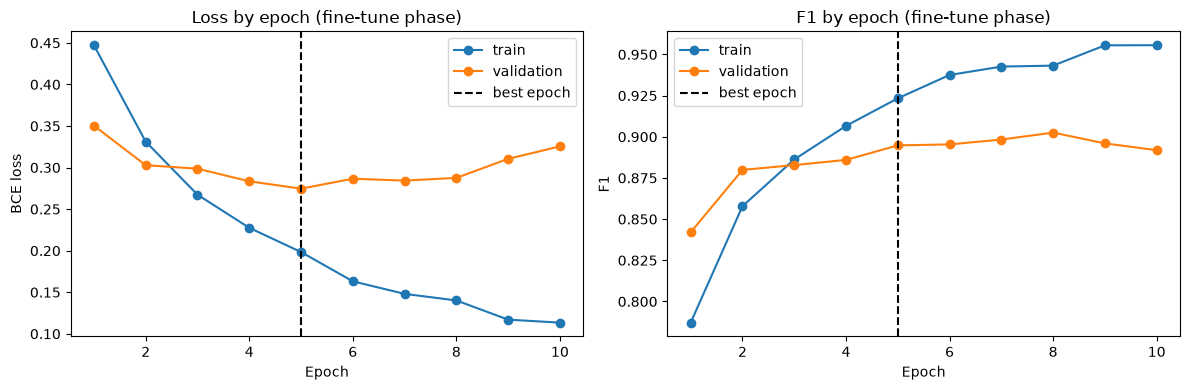

In [4]:
# Phase 1: train only the classifier head with the pretrained backbone frozen.
warmup_optimizer: AdamW = AdamW(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=vit_config["warmup_learning_rate"],
    weight_decay=vit_config["weight_decay"],
)

for epoch in range(1, vit_config["warmup_epochs"] + 1):
    train_metrics = train_one_epoch(model, dataloaders["train"], criterion, warmup_optimizer, device)
    val_metrics = evaluate(model, dataloaders["val"], criterion, device)
    print(
        f"[warmup] epoch {epoch}/{vit_config['warmup_epochs']} | "
        f"train loss {train_metrics.loss:.4f}, F1 {train_metrics.f1:.4f} | "
        f"val loss {val_metrics.loss:.4f}, F1 {val_metrics.f1:.4f}"
    )

# Phase 2: unfreeze only the last few transformer blocks and fine-tune those
# plus the head, keeping the earlier, more generic blocks frozen.
unfreeze_vit_blocks(model, num_blocks=vit_config["unfreeze_last_n_blocks"], head_attr="head")
print(f"Trainable parameters (last {vit_config['unfreeze_last_n_blocks']} blocks unfrozen): "
      f"{count_trainable_parameters(model):,}")

finetune_optimizer: AdamW = AdamW(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=vit_config["finetune_learning_rate"],
    weight_decay=vit_config["weight_decay"],
)

fit_result = fit(
    model=model,
    train_dataloader=dataloaders["train"],
    val_dataloader=dataloaders["val"],
    criterion=criterion,
    optimizer=finetune_optimizer,
    device=device,
    epochs=vit_config["finetune_epochs"],
    patience=vit_config["early_stopping_patience"],
    min_delta=vit_config["early_stopping_min_delta"],
    checkpoint_path=CHECKPOINT_PATH,
)

history: pd.DataFrame = pd.DataFrame(fit_result.history)
history.to_csv(METRICS_ROOT / "training_history.csv", index=False)
print(f"Best epoch: {fit_result.best_epoch}")
print(f"Best validation loss: {fit_result.best_val_loss:.4f}")
display(history)

# Learning curves for the fine-tune phase.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="validation")
axes[0].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[0].set_title("Loss by epoch (fine-tune phase)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_f1"], marker="o", label="train")
axes[1].plot(history["epoch"], history["val_f1"], marker="o", label="validation")
axes[1].axvline(fit_result.best_epoch, color="black", linestyle="--", label="best epoch")
axes[1].set_title("F1 by epoch (fine-tune phase)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_ROOT / "training_curves.png", dpi=150)
plt.show()

## Evaluation

Evaluate the fine-tuned model once on the previously untouched test split, using the same metrics and per-generator breakdown as the other models.

In [5]:
test_result: EvaluationResult = evaluate_predictions(
    model=model,
    dataloader=dataloaders["test"],
    criterion=criterion,
    device=device,
    threshold=0.5,
)

print("Test metrics:")
display(pd.Series(test_result.metrics.to_dict(), name="value"))
print("Per-generator metrics:")
display(test_result.per_generator)

Test metrics:


loss         0.291697
accuracy     0.890000
precision    0.880930
recall       0.901905
f1           0.891294
roc_auc      0.956613
Name: value, dtype: float64

Per-generator metrics:


,generator,n_ai,n_real,accuracy,precision,recall,f1,roc_auc
0,adm,150,150,0.913333,0.864706,0.980000,0.918750,0.985422
1,biggan,150,150,0.930000,0.886228,0.986667,0.933754,0.986133
2,glide,150,150,0.920000,0.879518,0.973333,0.924051,0.976178
3,midjourney,150,150,0.830000,0.861314,0.786667,0.822300,0.918933
4,sdv1_5,150,150,0.893333,0.888158,0.900000,0.894040,0.965244
5,vqdm,150,150,0.846667,0.866197,0.820000,0.842466,0.915778
6,wukong,150,150,0.896667,0.921986,0.866667,0.893471,0.963556


## Save results

Save the checkpoint, metrics, predictions, and figures for this experiment, mirroring the other models' output layout under `results/`.

In [6]:
saved_paths: dict[str, Path] = save_evaluation_outputs(test_result, output_dir=METRICS_ROOT, figures_dir=FIGURES_ROOT)

print("Saved outputs:")
for name, path in saved_paths.items():
    print(f"  {name}: {path.relative_to(REPO_ROOT)}")

Saved outputs:
  metrics: results\metrics\vit_small\test_metrics.json
  predictions: results\metrics\vit_small\test_predictions.csv
  per_generator: results\metrics\vit_small\per_generator_metrics.csv
  confusion_matrix: results\figures\vit_small\confusion_matrix.png
  roc_curve: results\figures\vit_small\roc_curve.png
